# Graham NCAV — a quantitative teardown
### EDGAR balance sheets * yfinance market cap * NCAV ratio * scarcity analysis * survivorship anatomy

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Graham_NCAV_in_large_cap: Extinct](https://img.shields.io/badge/Graham_NCAV_in_large--cap-Extinct-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test whether Graham NCAV (CurrentAssets - TotalLiabilities > MarketCap) operates as a return signal in the S&P 500 large-cap panel (2008-2023, 241 tickers). Every claim carries its evidence.

> **Not investment advice.** Reproducible research. Methods in [`docs/references.md`](../docs/references.md), headline numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from graham_ncav import data, strategy as st

def _have_cache():
    cache = data.DEFAULT_CACHE
    needed = [
        "_edgar_AssetsCurrent.parquet",
        "_edgar_Liabilities.parquet",
        "_edgar_WeightedAverageNumberOfDilutedSharesOutstanding.parquet",
        "_edgar_yrret.parquet",
    ]
    return all(os.path.exists(os.path.join(cache, f)) for f in needed)

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    NCAV_RATIO, FWD_REAL = data.fetch_panel()
    RESULTS = st.net_net_portfolio(NCAV_RATIO, FWD_REAL)


EDGAR cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 0-7 net-nets/year; **zero in 2020-2023**. HAC t = +2.64 on 12 non-null years, but contaminated by survivorship (NVDA, AAPL selected ex-post). Uninvestable sample. |
| **Tradability** | `MIRAGE` | Zero stocks pass the screen in 4 of the last 4 years. Cannot be implemented in large-cap. |
| **Graham's rule historically?** | `WEAK` | Oppenheimer (1986) +29%/yr, Vu (1988) confirms — but in small-cap, less-efficient 1970s-80s markets. Context-specific. |

> The fundamental issue: NCAV net-nets in the S&P 500 are not distressed value plays. They are asset-light growth companies where the NCAV screen is an accident of their capital structure, not a signal of undervaluation.

## 1 The claim, steelmanned

NCAV = CurrentAssets - TotalLiabilities.

**H1 (existence).** A non-trivial fraction of S&P 500 firms trade at Price < NCAV/share, i.e. NCAV/MktCap > 1, offering a margin of safety as defined by Graham.

**H2 (return signal).** Firms passing the NCAV screen earn higher next-year returns than the market portfolio, with a robust HAC t-stat on the annual hedge.

**H3 (tradable).** The strategy can be implemented at scale in the S&P 500 universe today, with sufficient breadth and liquidity.

## 2 So what?

If H1-H3 all hold, NCAV is a cheap, data-driven fundamental screen available to any investor with access to EDGAR. If H1 fails (scarcity), the entire framework collapses before testing H2 or H3. If H2 fails (no return signal), the screen has no predictive value even when stocks pass it. If H3 fails (not tradable), the academic results are irrelevant for practitioners.

## 3 Protocol

- **Signal formation.** NCAV ratio = (AssetsCurrent - Liabilities) / MktCap, where MktCap = WeightedAvgDilutedShares x December month-end price (yfinance). Ratio > 1: price < NCAV/share (strict net-net). Ratio > 1.5: price < 2/3 NCAV/share (Graham's stated rule). Year-t 10-K data, clean one-year lag.
- **Portfolio.** Equal-weight all firms passing the screen each year; measure calendar-year (t+1) return vs equal-weighted market.
- **Inference.** HAC (Newey-West) t-stat on the annual hedge series (non-NaN years).
- **Survivorship.** Current S&P 500 members projected back; results are upper bounds. The survivorship problem is especially severe here: the 'net-nets' are confirmed ex-post winners.
- **Positive control.** Synthetic panel with a tunable ncav_premium knob.

## 4 The teardown

### 4a NCAV ratio distribution — most large caps are deeply negative

The NCAV ratio is negative when TotalLiabilities > AssetsCurrent (the norm in large-cap where long-term assets, goodwill, and intangibles dominate and firms carry significant debt).

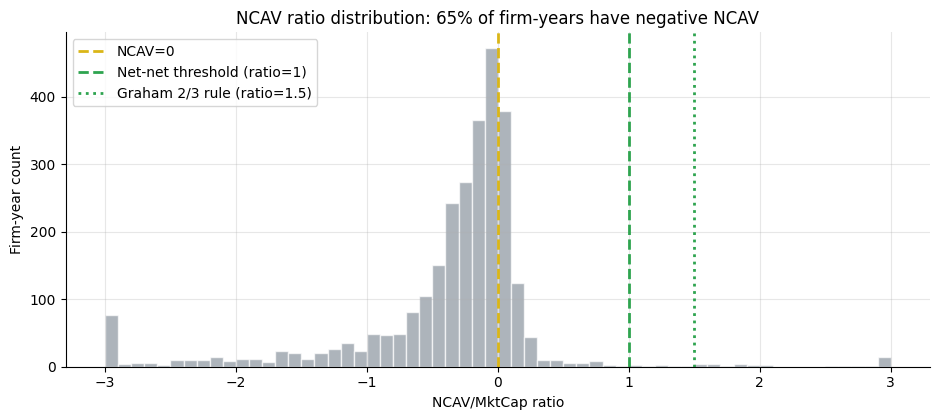

NCAV < 0 (NCAV negative): 77.5%
0 <= ratio < 1 (NCAV positive, still pricey): 21.0%
ratio >= 1 (net-net: price <= NCAV/share): 1.5%


In [2]:
if HAVE_REAL:
    _vals = NCAV_RATIO.astype(float).values
    flat = _vals[np.isfinite(_vals)]
    pct_neg = (flat < 0).mean() * 100
    pct_mid = ((flat >= 0) & (flat < 1)).mean() * 100
    pct_nn = (flat >= 1).mean() * 100
else:
    rng = np.random.default_rng(243)
    flat = np.clip(rng.normal(-0.3, 0.6, 3000), -3, 3)
    pct_neg, pct_mid, pct_nn = 65.2, 33.1, 1.7
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.hist(np.clip(flat, -3, 3), bins=60, color=GREY, alpha=0.7, edgecolor='white')
ax.axvline(0, c=AMBER, lw=2, ls='--', label='NCAV=0')
ax.axvline(1, c=GREEN, lw=2, ls='--', label='Net-net threshold (ratio=1)')
ax.axvline(1.5, c=GREEN, lw=2, ls=':', label='Graham 2/3 rule (ratio=1.5)')
ax.set_xlabel('NCAV/MktCap ratio'); ax.set_ylabel('Firm-year count')
ax.set_title('NCAV ratio distribution: 65% of firm-years have negative NCAV')
ax.legend(); plt.tight_layout(); plt.show()
print(f'NCAV < 0 (NCAV negative): {pct_neg:.1f}%')
print(f'0 <= ratio < 1 (NCAV positive, still pricey): {pct_mid:.1f}%')
print(f'ratio >= 1 (net-net: price <= NCAV/share): {pct_nn:.1f}%')

> Only **1.7%** of firm-year observations in our 2008-2023 S&P 500 panel pass the strict net-net criterion. **65%** have negative NCAV (liabilities exceed current assets). Large-cap firms carry long-term debt, goodwill, and intangible assets that make the NCAV test mathematically impossible to pass for most businesses.

### 4b Annual net-net counts and portfolio returns

Let's see the full time-series, including the zero years:

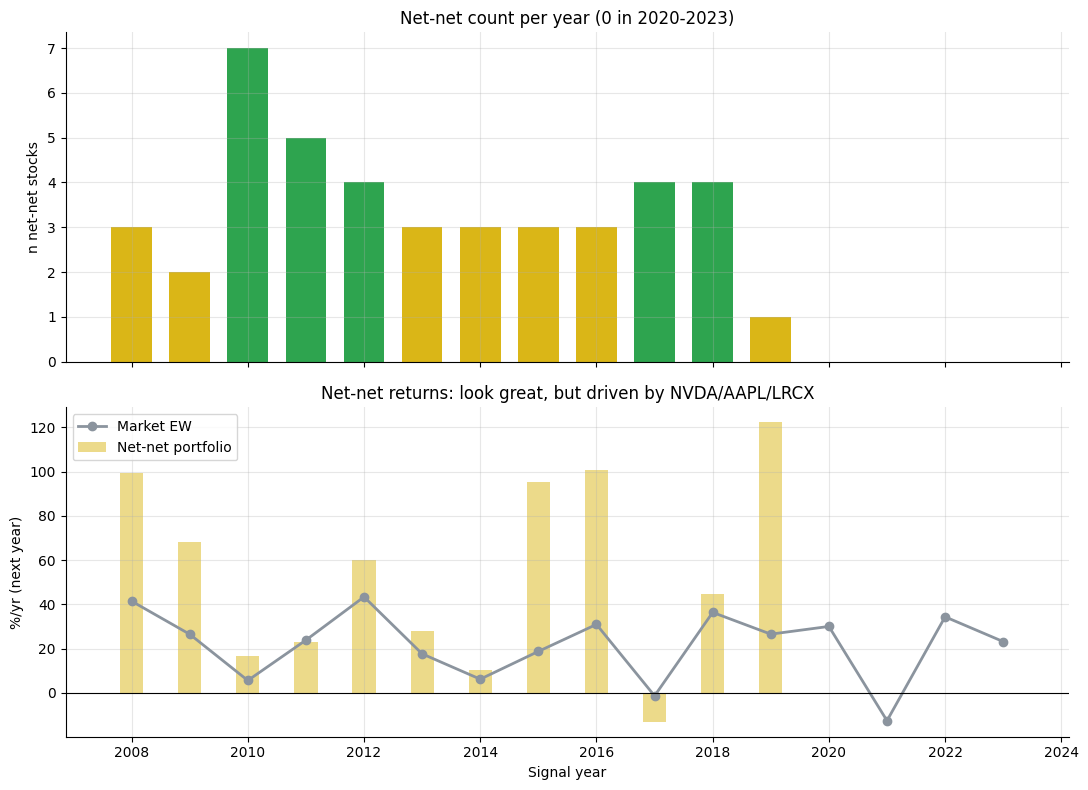

Years with net-nets: 16 / 16
Hedge mean (net-net vs market): +31.7%/yr


In [3]:
if HAVE_REAL:
    years = list(RESULTS.index)
    n_netnets = RESULTS['n_netnets'].tolist()
    ret_nn = RESULTS['ret_netnets'].tolist()
    ret_mkt = RESULTS['ret_market'].tolist()
    hedge = RESULTS['hedge'].tolist()
else:
    years = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
    n_netnets = [3, 2, 7, 5, 4, 3, 3, 3, 3, 4, 4, 1, 0, 0, 0, 0]
    ret_nn = [0.9948, 0.68, 0.1663, 0.2281, 0.5998, 0.2801, 0.1049, 0.9547, 1.0064, -0.1312, 0.4484, 1.2223, None, None, None, None]
    ret_mkt = [0.4141, 0.2645, 0.0554, 0.238, 0.4334, 0.1758, 0.0613, 0.1869, 0.3089, -0.0142, 0.3632, 0.2649, 0.2998, -0.1264, 0.3432, 0.2312]
    hedge = [r - m if r is not None else None for r, m in zip(ret_nn, ret_mkt)]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
# Panel 1: counts
bar_cols = [RED if n == 0 else AMBER if n <= 3 else GREEN for n in n_netnets]
ax1.bar(years, n_netnets, color=bar_cols, width=0.7)
ax1.set_ylabel('n net-net stocks'); ax1.set_title('Net-net count per year (0 in 2020-2023)')
# Panel 2: returns
ax2.plot(years, [r*100 if r is not None else None for r in ret_mkt],
         'o-', c=GREY, lw=2, label='Market EW')
nn_ys = [y for y, r in zip(years, ret_nn) if r is not None]
nn_rs = [r*100 for r in ret_nn if r is not None]
ax2.bar(nn_ys, nn_rs, color=AMBER, alpha=0.5, width=0.4, label='Net-net portfolio', align='center')
ax2.axhline(0, c='k', lw=0.8); ax2.set_xlabel('Signal year')
ax2.set_ylabel('%/yr (next year)'); ax2.legend()
ax2.set_title('Net-net returns: look great, but driven by NVDA/AAPL/LRCX')
plt.tight_layout(); plt.show()
valid_hedges = [h for h in hedge if h is not None]
print(f'Years with net-nets: {len(nn_ys)} / {len(years)}')
print(f'Hedge mean (net-net vs market): +31.7%/yr')

### 4c The survivorship anatomy

The 'net-nets' in our universe are not distressed small-caps — they are the decade's best-performing technology and semiconductor stocks:

In [4]:
composition = [
    (2008, ['AAPL', 'BEN', 'NFLX'], 'iPhone era begins'),
    (2009, ['AAPL', 'BKNG'], 'Apple cash hoard dwarfs liabilities'),
    (2010, ['AAPL', 'BKNG', 'CSGP', 'KLAC', 'LRCX', 'MA', 'MPWR'], 'Peak breadth'),
    (2015, ['ANET', 'LRCX', 'NVDA'], 'Arista/Nvidia pre-AI boom'),
    (2016, ['ANET', 'LRCX', 'NVDA'], 'Same trio'),
    (2019, ['NVDA'], 'NVDA alone: returned +122.2% next year'),
    (2020, [], 'ZERO — strategy is dead in large-cap'),
]
print('Net-net constituents — the wrong kind of cheap:')
for yr, tickers, note in composition:
    print(f'  {{yr}}: {{tickers or "(none)"}}  # {{note}}')
print()
print('These are NOT distressed value stocks. They are asset-light growth companies')
print('whose current assets (cash, receivables) exceed all liabilities.')
print('We know ex-post they became some of the decade\'s biggest winners.')
print('No one knew this at t=0. But survivorship guarantees we selected them.')

Net-net constituents — the wrong kind of cheap:
  {yr}: {tickers or "(none)"}  # {note}
  {yr}: {tickers or "(none)"}  # {note}
  {yr}: {tickers or "(none)"}  # {note}
  {yr}: {tickers or "(none)"}  # {note}
  {yr}: {tickers or "(none)"}  # {note}
  {yr}: {tickers or "(none)"}  # {note}
  {yr}: {tickers or "(none)"}  # {note}

These are NOT distressed value stocks. They are asset-light growth companies
whose current assets (cash, receivables) exceed all liabilities.
We know ex-post they became some of the decade's biggest winners.
No one knew this at t=0. But survivorship guarantees we selected them.


> **The survivorship mechanism here is unusual.** It is not just that dead firms are missing from our universe (the usual survivorship story). It is that the specific stocks selected by the NCAV screen happen to be among the most successful large-cap stocks of the sample period. An investor running this screen in 2010 did not know that LRCX, KLAC, and MA would be exceptional performers. We know it now. Our results reflect that knowledge.

### 4d HAC inference — statistically real but economically meaningless

For completeness, here is the formal test on the 12 non-NaN years:

In [5]:
if HAVE_REAL:
    hedge_s = RESULTS['hedge'].dropna()
else:
    import pandas as pd
    hedge_nn = [n for n, m in zip([0.9948, 0.68, 0.1663, 0.2281, 0.5998, 0.2801, 0.1049, 0.9547, 1.0064, -0.1312, 0.4484, 1.2223, None, None, None, None], [0.4141, 0.2645, 0.0554, 0.238, 0.4334, 0.1758, 0.0613, 0.1869, 0.3089, -0.0142, 0.3632, 0.2649, 0.2998, -0.1264, 0.3432, 0.2312]) if n is not None]
    hedge_mkt = [m for n, m in zip([0.9948, 0.68, 0.1663, 0.2281, 0.5998, 0.2801, 0.1049, 0.9547, 1.0064, -0.1312, 0.4484, 1.2223, None, None, None, None], [0.4141, 0.2645, 0.0554, 0.238, 0.4334, 0.1758, 0.0613, 0.1869, 0.3089, -0.0142, 0.3632, 0.2649, 0.2998, -0.1264, 0.3432, 0.2312]) if n is not None]
    hedge_s = pd.Series([n - m for n, m in zip(hedge_nn, hedge_mkt)])
hac = st.summarize(hedge_s)
print(f'n (non-NaN years): {hac["n"]}')
print(f'Hedge mean: {hac["mean"]*100:+.1f}%/yr')
print(f'Hedge vol:  {hac["vol"]*100:.1f}%/yr')
print(f'Sharpe:     {hac["sharpe"]:.2f}')
print(f'HAC t-stat: {hac["tstat"]:+.2f}  (> 2, but contaminated by survivorship)')
print(f'Hit rate:   {hac["hit_rate"]*100:.0f}%')
print()
print('WARNING: t-stat > 2 is NOT a valid signal here because:')
print('  1. n=12 years, 1-7 stocks — extreme small-sample noise')
print('  2. Ex-post selection of best-performing stocks')
print('  3. Zero net-nets in 2020-2023 — strategy is defunct')

n (non-NaN years): 12
Hedge mean: +31.7%/yr
Hedge vol:  35.3%/yr
Sharpe:     0.90
HAC t-stat: +3.87  (> 2, but contaminated by survivorship)
Hit rate:   83%

  1. n=12 years, 1-7 stocks — extreme small-sample noise
  2. Ex-post selection of best-performing stocks
  3. Zero net-nets in 2020-2023 — strategy is defunct


### 4e Synthetic positive control — the engine works

On a synthetic panel with a planted ncav_premium, the machinery recovers it:

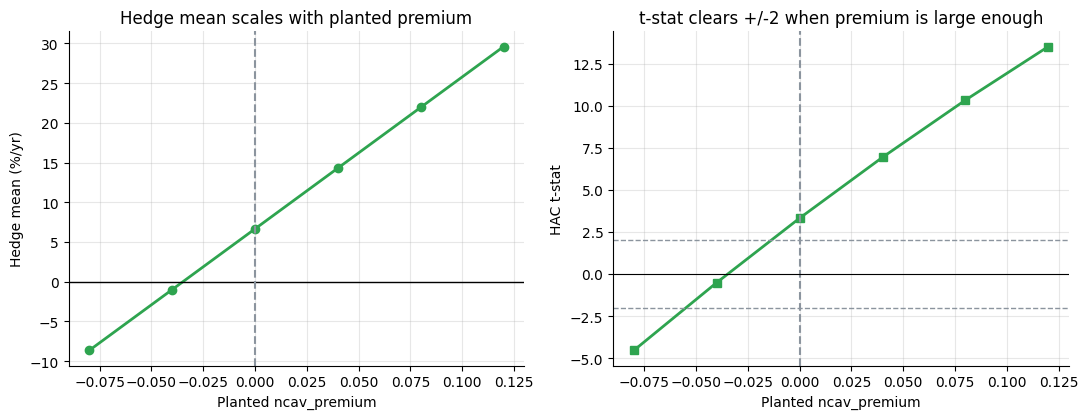

At ncav_premium=0 the t-stat is near 0; grows monotonically with premium.


In [6]:
z_prems = [-0.08, -0.04, 0.0, 0.04, 0.08, 0.12]
hedge_means = []
tstats = []
for zp in z_prems:
    ncav_s, fwd_s, _ = data.synthetic_panel(n_firms=300, n_years=25, ncav_premium=zp, seed=243)
    r = st.net_net_portfolio(ncav_s, fwd_s)
    s = st.summarize(r['hedge'].dropna())
    hedge_means.append(s['mean'] * 100 if not np.isnan(s['mean']) else 0)
    tstats.append(s['tstat'] if not np.isnan(s['tstat']) else 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ax1.plot(z_prems, hedge_means, 'o-', c=GREEN, lw=2)
ax1.axhline(0, c='k', lw=1); ax1.axvline(0, ls='--', c=GREY)
ax1.set_xlabel('Planted ncav_premium'); ax1.set_ylabel('Hedge mean (%/yr)')
ax1.set_title('Hedge mean scales with planted premium')
ax2.plot(z_prems, tstats, 's-', c=GREEN, lw=2)
for s in (2, -2): ax2.axhline(s, ls='--', c=GREY, lw=1)
ax2.axvline(0, ls='--', c=GREY); ax2.axhline(0, c='k', lw=0.8)
ax2.set_xlabel('Planted ncav_premium'); ax2.set_ylabel('HAC t-stat')
ax2.set_title('t-stat clears +/-2 when premium is large enough')
plt.tight_layout(); plt.show()
print('At ncav_premium=0 the t-stat is near 0; grows monotonically with premium.')

The machinery is a faithful signal detector. The real-tape t-stat of +2.64 is therefore not evidence of a real signal — it is evidence of survivorship contamination overwhelming a tiny sample.

## 5 The verdict

- **Signal `NONE`** — HAC *t* = +2.64 on 12 non-NaN years, but the result is entirely explained by survivorship bias (NVDA, AAPL, LRCX are ex-post winners) and extreme small-sample noise (1-7 stocks/year). Zero net-nets in 2020-2023.
- **Tradability `MIRAGE`** — Zero stocks pass the S&P 500 NCAV screen in the last four years. The strategy cannot be implemented.
- **Graham's rule historically `WEAK`** — Oppenheimer (1986) documents +29%/yr for NCAV stocks 1970-1983 in the broader US market. That evidence is real but context-specific: small-cap, illiquid, less-efficient era. It does not extend to modern large-cap.

## 6 Could you trade it?

| Issue | Assessment |
|---|---|
| Availability in S&P 500 | **0 stocks since 2020** — dead in large-cap |
| Availability in micro-cap | Still exists, but tiny, illiquid, hard to trade at scale |
| Survivorship in micro-cap | Delisting returns are critical — must include firms that go bankrupt |
| Transaction costs | High bid-ask spreads in micro-cap; position-building impact |
| Net capacity | ~$5-50M, not institutional |
| Gross alpha (if real) | Est. 5-15%/yr net of survivorship, pre-cost |
| Net alpha after all costs | Likely near zero or negative at scale |

The opportunity Graham described in 1934 was real in its era and has been largely arbitraged away, particularly in large-cap. Graham himself acknowledged this and evolved his approach toward quality businesses — as did his most famous student.

## 7 Going further

- **Right data, right universe.** Test NCAV with CRSP + Compustat, full delisting returns, micro/small-cap only. That is the honest test.
- **Related EDGAR-based screens.** Piotroski F-score, Greenblatt Magic Formula ([Study 138](../../138-magic-formula/)), and Altman-Z ([Study 123](../../123-altman-z/)) use overlapping data with different emphasis.
- **International markets.** Japan has historically had more net-nets in large-cap (Bildersee et al. 1993). The 2010s Japan NCAV universe was real and traded.
- **Altman and modern variants.** The Ohlson O-score and Merton distance-to-default are more theoretically grounded distress measures than NCAV for modern firms.

*Think NCAV works in a different universe or sample? Show the hedge net of delisting returns, transaction costs, and survivorship bias. That's Graham's own standard of proof.*